# Rompy-Oceanum: SWAN Model Submission to Prax

This notebook demonstrates how to use the rompy-oceanum extension to submit SWAN wave model runs to the Prax pipeline service. The workflow is designed to streamline the process of configuring, submitting, and monitoring ocean wave models in a cloud environment.

## What is this demo showing?

1. **Loading a SWAN model configuration** from a YAML file
2. **Creating a ModelRun object** using rompy's declarative model configuration
3. **Submitting the model run to Prax** - a service for orchestrating containerized workloads
4. **Monitoring pipeline status and logs** in real-time
5. **Retrieving results** when the model run completes

This demonstration showcases how rompy-oceanum extends the core rompy package with cloud deployment capabilities, allowing researchers and engineers to run computationally intensive wave models in a scalable cloud environment.

## Setup and Dependencies

First, let's import the required libraries. We need rompy for the core model functionality and rompy_oceanum for the Prax integration.

In [1]:
import json
import yaml
import rompy
import rompy_oceanum

import warnings
warnings.filterwarnings("ignore")


# Optional: display versions
print(f"Rompy version: {rompy.__version__}")
print(f"Rompy-Oceanum version: {rompy_oceanum.__version__}")

/home/tdurrant/.virtualenvs/rompy-oceanum-crum/lib/python3.13/site-packages/pydantic/_internal/_model_construction.py:64: UserWarning: `serialize_model` overrides an existing Pydantic `@model_serializer` decorator
  warnings.warn(f'`{k}` overrides an existing Pydantic `{existing.decorator_info.decorator_repr}` decorator')
/home/tdurrant/.virtualenvs/rompy-oceanum-crum/lib/python3.13/site-packages/pydantic/_internal/_model_construction.py:64: UserWarning: `validate_rheol_steps` overrides an existing Pydantic `@model_validator` decorator
  warnings.warn(f'`{k}` overrides an existing Pydantic `{existing.decorator_info.decorator_repr}` decorator')


Rompy version: 0.2.4
Rompy-Oceanum version: pre-alpha


## Loading Model Configuration

Rompy uses a declarative approach to model configuration. This allows for clear, structured definitions of model parameters that can be stored in YAML or JSON format.

The example configuration file (`example_swan.yaml`) defines:
- Time period for the model run
- Grid specifications
- Input data sources (from DataMesh)
- Boundary conditions
- Physical parameters
- Output specifications

Let's load this configuration:

In [2]:
# Load model configuration from YAML file
model_config = yaml.safe_load(open("example_swan.yaml"))

# Display some key configuration elements
print(f"Model period: {model_config['period']}")
print(f"Grid center location: {model_config['config']['cgrid']['grid']['xp']}°E, {model_config['config']['cgrid']['grid']['yp']}°N")
print(f"Domain size: {model_config['config']['cgrid']['grid']['xlen']}° × {model_config['config']['cgrid']['grid']['ylen']}°")

Model period: {'start': '20230101T000000', 'duration': '1d', 'interval': '1h'}
Grid center location: 110.0°E, -35.2°N
Domain size: 7.5° × 12.5°


## Creating a ModelRun Object

Now we'll create a ModelRun object using the configuration we loaded. This object represents a complete specification of the model run and its parameters.

In [3]:
# Create a rompy model configuration
model_run = rompy_oceanum.model_extension.OceanumModelRun(**model_config)

# Display the model run object
print(model_run)


run_id: run_id
period: 
	Start: 2023-01-01 00:00:00
	End: 2023-01-02 00:00:00
	Duration: 1 day, 0:00:00
	Interval: 1:00:00
	Include End: True

output_dir: /app
config: <class 'rompy.swan.config.SwanConfigComponents'>



## Optional: Examining the Model Configuration

We can dump the model configuration to examine it. This is useful for debugging or verification purposes.

In [4]:
# Uncomment to view and save the model configuration
# model_dict = model_run.dump_inputs_dict()
# model_json = model_run.dump_inputs_json()
# 
# # Write to files
# yaml.dump(model_dict, open("model_config_dump.yaml", "w"))
# json.dump(model_json, open("model_config_dump.json", "w"))
# 
# # Show a snippet of the configuration
# print(json.dumps(model_json, indent=2)[:500] + "...")

## Optional: Usual rompy functionality works for locally checking things out

Lets just plot the grid for now. A more comprehensive example can be found in the rompy documentation 

e.g. https://github.com/rom-py/rompy/blob/main/notebooks/swan/example_declarative.ipynb

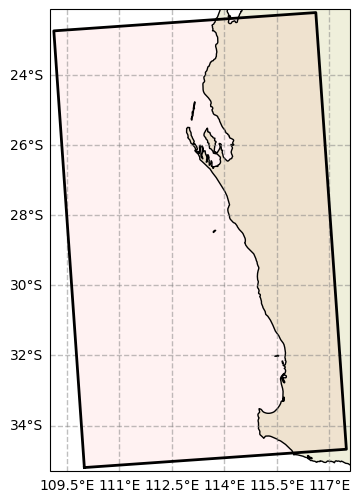

In [5]:
fig, ax = model_run.config.grid.plot(fscale=6)

## Submitting the Model Run to Prax

With our model configuration complete, we can now submit it to Prax for execution. Prax is a pipeline service that orchestrates containerized workloads, allowing models to run on cloud infrastructure.

The `submit_to_prax` method handles:
1. Authentication with the Prax service
2. Converting the model configuration to Prax's expected format
3. Submitting the job
4. Returning a result object for monitoring

In [6]:
# Submit to Prax pipeline
result = model_run.submit_to_prax(
    pipeline_name="swan-from-rompy",
    user="t.durrant@oceanum.science",  # Replace with your Prax username
    org="oceanum",                     # Replace with your organization
    project="rompy-oceanum",           # Project name
    stage="dev",                       # Environment stage (dev, test, prod, etc.)
)

print(f"Submitted run to Prax. Run ID: {result.run_id}")

INFO:rompy_oceanum.model_extension:Submitting swan-from-rompy pipeline to Prax
INFO:rompy_oceanum.prax:Found run ID in last_run.name: pipeline-swan-from-rompy-d891-dev-4x7g2
INFO:rompy_oceanum.prax:Using run ID from API response: pipeline-swan-from-rompy-d891-dev-4x7g2
INFO:rompy_oceanum.model_extension:Pipeline submitted successfully with run ID: pipeline-swan-from-rompy-d891-dev-4x7g2


Submitted run to Prax. Run ID: pipeline-swan-from-rompy-d891-dev-4x7g2


## Monitoring Pipeline Status

Once the model is submitted, we can monitor its status to track progress. The `result` object provides methods to check the current state of the pipeline.

In [7]:
# Get initial status
status = result.get_status()

# Display a well-formatted summary of the status
print("Initial Pipeline Status:")
result.summary_status(status)

INFO:rompy_oceanum.prax:Successfully retrieved run status from https://prax.oceanum.io/api/pipeline-runs/pipeline-swan-from-rompy-d891-dev-4x7g2


Initial Pipeline Status:

                              PIPELINE RUN SUMMARY                              

Run ID:             pipeline-swan-from-rompy-d891-dev-4x7g2
Organization:       oceanum
Project:            rompy-oceanum
Stage:              dev
Status:             Running
Started:            2025-04-01T07:02:58Z
Last Updated:       2025-04-01T07:02:58.275Z




## Viewing Pipeline Logs

We can also retrieve and display logs from the pipeline execution. The `get_logs` method supports real-time streaming of logs, which is useful for monitoring the model's progress and debugging any issues.

In [8]:
# Get logs without streaming (will get the current logs)
# print("Current logs:")
# logs = result.get_logs(follow=False, tail=20)  # Get the last 20 lines
# print(logs)

## Optional: Streaming Logs in Real-time

For real-time monitoring, we can stream logs as they are generated. This is particularly useful for long-running model executions.

**Note:** Running the cell below will stream logs continuously until interrupted. To stop streaming, click the "Interrupt the kernel" button or press Ctrl+C twice.

In [ ]:
# Stream logs in real-time
print("Streaming logs (press Interrupt kernel button to stop)...")
try:
    logs = result.get_logs(follow=True, stream_to_stdout=True)
    logs = result.get_logs(follow=True, stream_to_stdout=True) #There are three here because there is a prax bug that drop the stream at the end of each task
    logs = result.get_logs(follow=True, stream_to_stdout=True)
except KeyboardInterrupt:
    print("\nLog streaming interrupted.")

INFO:rompy_oceanum.prax:Streaming logs from: https://prax.oceanum.io/api/pipeline-runs/pipeline-swan-from-rompy-d891-dev-4x7g2/logs with follow=True


Streaming logs (press Interrupt kernel button to stop)...
Task prepare [main]: 2025-04-01T07:03:06.559386543Z time="2025-04-01T07:03:06.558Z" level=info msg="capturing logs" argo=true 
Task prepare [main]: 2025-04-01T07:03:09.573996649Z /usr/local/lib/python3.12/site-packages/pydantic/_internal/_model_construction.py:64: UserWarning: `serialize_model` overrides an existing Pydantic `@model_serializer` decorator 
Task prepare [main]: 2025-04-01T07:03:09.574026969Z   warnings.warn(f'`{k}` overrides an existing Pydantic `{existing.decorator_info.decorator_repr}` decorator') 
Task prepare [main]: 2025-04-01T07:03:09.621867265Z /usr/local/lib/python3.12/site-packages/pydantic/_internal/_model_construction.py:64: UserWarning: `validate_rheol_steps` overrides an existing Pydantic `@model_validator` decorator 
Task prepare [main]: 2025-04-01T07:03:09.621902855Z   warnings.warn(f'`{k}` overrides an existing Pydantic `{existing.decorator_info.decorator_repr}` decorator') 
Task prepare [main]: 20

INFO:rompy_oceanum.prax:Streaming logs from: https://prax.oceanum.io/api/pipeline-runs/pipeline-swan-from-rompy-d891-dev-4x7g2/logs with follow=True


Task run [main]: 2025-04-01T07:03:32.395439042Z time="2025-04-01T07:03:32.394Z" level=info msg="capturing logs" argo=true 
Task run [main]: 2025-04-01T07:03:32.815663817Z  
Task run [main]: 2025-04-01T07:03:32.815698537Z  SWAN is preparing computation 
Task run [main]: 2025-04-01T07:03:32.815704567Z  
Task run [main]: 2025-04-01T07:03:32.824883106Z  iteration    1; sweep 1 
Task run [main]: 2025-04-01T07:03:32.832933846Z +iteration    1; sweep 2 
Task run [main]: 2025-04-01T07:03:32.841626755Z +iteration    1; sweep 3 
Task run [main]: 2025-04-01T07:03:32.852243884Z +iteration    1; sweep 4 
Task run [main]: 2025-04-01T07:03:32.862564443Z  not possible to compute, first iteration 
Task run [main]: 2025-04-01T07:03:32.862582483Z  
Task run [main]: 2025-04-01T07:03:32.862586983Z  iteration    2; sweep 1 
Task run [main]: 2025-04-01T07:03:32.872489962Z +iteration    2; sweep 2 
Task run [main]: 2025-04-01T07:03:32.884756801Z +iteration    2; sweep 3 
Task run [main]: 2025-04-01T07:03:32.8

INFO:rompy_oceanum.prax:Streaming logs from: https://prax.oceanum.io/api/pipeline-runs/pipeline-swan-from-rompy-d891-dev-4x7g2/logs with follow=True


Task register [main]: 2025-04-01T07:03:55.015562916Z time="2025-04-01T07:03:55.014Z" level=info msg="capturing logs" argo=true 
Task register [main]: 2025-04-01T07:03:58.079092848Z /usr/local/lib/python3.12/site-packages/pydantic/_internal/_model_construction.py:64: UserWarning: `serialize_model` overrides an existing Pydantic `@model_serializer` decorator 
Task register [main]: 2025-04-01T07:03:58.079134348Z   warnings.warn(f'`{k}` overrides an existing Pydantic `{existing.decorator_info.decorator_repr}` decorator') 
Task register [main]: 2025-04-01T07:03:58.128133373Z /usr/local/lib/python3.12/site-packages/pydantic/_internal/_model_construction.py:64: UserWarning: `validate_rheol_steps` overrides an existing Pydantic `@model_validator` decorator 
Task register [main]: 2025-04-01T07:03:58.128177824Z   warnings.warn(f'`{k}` overrides an existing Pydantic `{existing.decorator_info.decorator_repr}` decorator') 
Task register [main]: 2025-04-01T07:03:59.393468777Z â­âââââââ

## Waiting for Completion

We can wait for the model run to complete before proceeding. This is useful for workflows that need to process the results immediately.

In [ ]:
# Wait for the model run to complete
# print("Waiting for completion...")
# try:
#     result.wait_for_completion()
#     print("Model run completed!")
# except Exception as e:
#     print(f"Error while waiting for completion: {str(e)}")

## Checking Final Status

Once the model run is complete, we can check its final status to see if it succeeded or failed.

In [ ]:
# Get final status
final_status = result.get_status()
print("\nFinal Pipeline Status:")
result.summary_status(final_status)

## Retrieving Results from Prax (Future Feature)

In the future, Prax will support downloading model outputs directly. For now, this feature is not yet implemented.

In [ ]:
# Future feature - not yet implemented in Prax
'''
print("Downloading outputs...")
result.download_outputs(target_dir="./outputs")
'''

## Retrieving Results from Datamesh 

Data can then be used from datamesh as usual

In [13]:
from oceanum.datamesh import Connector
#Put your datamesh token in the Jupyterlab settings, or as argument in the constructor below
datamesh=Connector()
oceanum_rompy_run_id_grid_grid_914c61=datamesh.query({
  "datasource": "oceanum-rompy-run_id-grid_grid",
  "description": "oceanum run_id grid  parameters",
  "variables": [
    "hs"
  ],
  "id": "914c61df167fc381fab2f0ccc9e84c90",
  "label": "oceanum-rompy-run_id-grid_grid_914c61"
})

Using datamesh API version 0
you are using version 1.0.4 of the oceanum_python which is the latest version available.


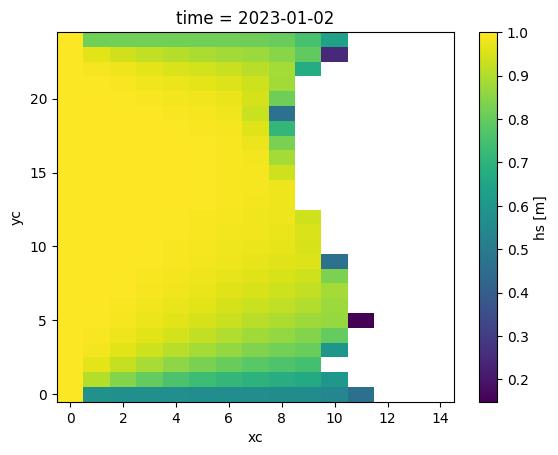

In [15]:
oceanum_rompy_run_id_grid_grid_914c61.hs.isel(time=-1).plot()

## Conclusion

This notebook has demonstrated the key features of the rompy-oceanum extension:

1. Configuring a SWAN wave model using rompy's declarative approach
2. Submitting the model to Prax for cloud execution
3. Monitoring the pipeline status and logs
4. Waiting for completion and retrieving results

This workflow enables efficient, scalable execution of wave models in a cloud environment, making it easier to conduct research and engineering studies that require significant computational resources.